<a href="https://colab.research.google.com/github/Lilycampbell0/Lily_Campbell_Portfolio/blob/main/Linear_Programming_and_Fairness_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shapely
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import random as random
from google.colab import drive
drive.mount('/content/drive')
from shapely.geometry import MultiPoint

Mounted at /content/drive


# Linear Programming and Fairness Challenge
This is taken from a real study of Israeli–Palestinian conflict in East Jerusalem. Out of respect for
the massive human toll of the Israeli–Palestinian conflict, I’ll make sure to put all of our fairness
words in quotes below, to emphasize how inadequate they are to really provide fairness in the
sense of justice.
A researcher identified six contentious sites for the Israeli and Palestinian people, then conducted
interviews with leaders on both sides to estimate relative weight on the importance of controlling
the different zones.

A researcher identified six contentious sites for the Israeli and Palestinian people, then conducted
interviews with leaders on both sides to estimate relative weight on the importance of controlling
the different zones.
Palestinian preference weights, thought of as percent of total value:


* Palestinian neighborhoods outside the Old City: 19% of the total.
* Muslim and Christian Quarters in the Old City: 22%.
* Al-Haram al-Sharif/Temple Mount1: 48%.
* Jewish and Armenian Quarters in the Old City: 6%.
* Western Wall: 4%.
* Israeli neighborhoods outside the Old City: 1%.

Israeli weights:
* Palestinian neighborhoods outside the Old City: 0%.
* Muslim and Christian Quarters in the Old City: 9.5%.
* Al-Haram al-Sharif/Temple Mount: 22%.
* Jewish and Armenian Quarters in the Old City: 18%.
* Western Wall: 31%.
* Israeli neighborhoods outside the Old City: 19.5%.

Of course, many would say that these sites are not realistically divisible. Ignoring that for a moment, find a division that would be optimal for the associated linear program.


In [5]:
# A are inequalities of cols of d adding to 1, and the equity constraint
A = np.array([
             [1, 0, 0, 0, 0, 0, 1, 0, 0, 0 ,0 ,0 ],
              [-1, 0, 0, 0, 0, 0, -1, 0, 0, 0 ,0 ,0],
              [0, 1, 0, 0, 0, 0, 0, 1, 0, 0 ,0 ,0 ],
              [0, -1, 0, 0, 0, 0, 0, -1, 0, 0 ,0 ,0 ],
              [0, 0, 1, 0, 0, 0, 0, 0, 1, 0 ,0 ,0 ],
              [0, 0, -1, 0, 0, 0, 0, 0, -1, 0 ,0 ,0 ],
              [0, 0, 0, 1, 0, 0, 0, 0, 0, 1 ,0 ,0 ],
              [0, 0, 0, -1, 0, 0, 0, 0, 0, -1 ,0 ,0 ],
              [0, 0, 0, 0, 1, 0, 0, 0, 0, 0 ,1 ,0 ],
              [0, 0, 0, 0, -1, 0, 0, 0, 0, 0 ,-1 ,0 ],
              [0, 0, 0, 0, 0, 1, 0, 0, 0, 0 ,0 ,1 ],
              [0, 0, 0, 0, 0, -1, 0, 0, 0, 0 ,0 ,-1 ],
              [.19, .22, .48, .06, .04, .01, 0, -.095, -.22, -.18, -.31, -.195],
              [-.19, -.22, -.48, -.06, -.04, -.01, 0, .095, .22, .18, .31, .195]
              ])

b = np.array([1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 0,0])
#is taste matrix
c = np.array([.19, .22, .48, .06, .04, .01, 0, .095, .22, .18, .31, .195])
# Here we define a 12-dimensional vector x, which we call x_vec in our code
x_vec = cp.Variable(12)
objective = cp.Maximize(cp.sum(c.T @ x_vec))
#These constraints include the equity condition 
#matrix_prob = cp.Problem(objective, constraints = [A@x_vec <= b, x_vec >=0, x_vec <=1])
#matrix_solution = matrix_prob.solve()
#print("d11 {:.3f}".format(x_vec.value[0]))
#print("d12 {:.3f}".format(x_vec.value[1]))
#print("d13 {:.3f}".format(x_vec.value[2]))
#print("d14 {:.3f}".format(x_vec.value[3]))
#print("d15 {:.3f}".format(x_vec.value[4]))
##print("d16 {:.3f}".format(x_vec.value[5]))
#print("d21 {:.3f}".format(x_vec.value[6]))
#print("d22 {:.3f}".format(x_vec.value[7]))
#print("d23 {:.3f}".format(x_vec.value[8]))
#print("d24 {:.3f}".format(x_vec.value[9]))
#print("d25 {:.3f}".format(x_vec.value[10]))
#print("d26 {:.3f}".format(x_vec.value[11]))

In [6]:
# Binary allocation Genrator
# Number of possible Binary Allocations is 64 (2^6), of these those are fair which are at least as good as 1/M
# Can write a while loop creating all possible matricies, then checking fairness and equitiablity of solution
def change_d():
  d11= np.random.randint(2)
  if (d11 == 0):
    d21 = 1
  else:
    d21 = 0
  d12 = np.random.randint(2)
  if (d12 == 0):
    d22 = 1
  else:
    d22 = 0
  d13 = np.random.randint(2)
  if (d13 == 0):
    d23 = 1
  else:
    d23 = 0
  d14 = np.random.randint(2) 
  if (d14==0):
    d24 = 1
  else:
    d24 = 0
  d15 = np.random.randint(2)
  if (d15 == 0):
    d25 = 1
  else:
    d25 = 0
  d16 = np.random.randint(2)
  if (d16 == 0):
    d26 =1
  else:
    d26 = 0
  return d11, d12, d13, d14, d15, d16, d21, d22, d23, d24, d25, d26

a,b,c,d,e,f,g,h,i,j,k,l = change_d()
D = np.array([
              [a,b,c,d,e,f],
              [g,h,i,j,k,l]
])
T = np.array([
              [.19, .22, .48, .06, .04, .01],
              [0, .095, .22, .18, .31, .195]
])

x=0
step = 0
set_v =[]
while (x <= 1000):
  a,b,c,d,e,f,g,h,i,j,k,l = change_d()
  D = np.array([
              [a,b,c,d,e,f],
              [g,h,i,j,k,l]
  ])
  v11 = T[0] @ D[0]
  v22 = T[1] @ D[1]
  if ((v11 >= .5) and (v22 >=.5)):
    set_v.insert(step, [v11,v22])
    print(step,D)
    step = step + 1
    x= x+ 1
  else:
    x = x+ 1

i=0
for point in set_v:
  print(i, point[0], point[1])
  i = i+ 1

0 [[0 1 1 0 0 0]
 [1 0 0 1 1 1]]
1 [[0 1 1 0 0 0]
 [1 0 0 1 1 1]]
2 [[0 1 1 0 0 0]
 [1 0 0 1 1 1]]
3 [[1 1 1 1 0 0]
 [0 0 0 0 1 1]]
4 [[0 0 1 1 0 0]
 [1 1 0 0 1 1]]
5 [[0 1 1 1 0 0]
 [1 0 0 0 1 1]]
6 [[0 1 1 0 0 0]
 [1 0 0 1 1 1]]
7 [[0 1 1 1 0 0]
 [1 0 0 0 1 1]]
8 [[1 0 1 1 0 0]
 [0 1 0 0 1 1]]
9 [[1 1 1 1 0 0]
 [0 0 0 0 1 1]]
10 [[0 0 1 1 0 0]
 [1 1 0 0 1 1]]
11 [[1 1 1 1 0 0]
 [0 0 0 0 1 1]]
12 [[1 1 1 1 0 0]
 [0 0 0 0 1 1]]
13 [[1 0 1 0 0 0]
 [0 1 0 1 1 1]]
14 [[1 0 1 0 0 1]
 [0 1 0 1 1 0]]
15 [[1 0 1 1 0 0]
 [0 1 0 0 1 1]]
16 [[1 1 1 1 0 0]
 [0 0 0 0 1 1]]
17 [[0 1 1 1 0 0]
 [1 0 0 0 1 1]]
18 [[1 0 1 0 0 1]
 [0 1 0 1 1 0]]
19 [[0 0 1 1 0 0]
 [1 1 0 0 1 1]]
20 [[1 0 1 0 0 0]
 [0 1 0 1 1 1]]
21 [[1 1 1 0 0 0]
 [0 0 0 1 1 1]]
22 [[0 0 1 1 0 0]
 [1 1 0 0 1 1]]
23 [[0 0 1 1 0 0]
 [1 1 0 0 1 1]]
24 [[1 0 1 0 0 1]
 [0 1 0 1 1 0]]
25 [[0 0 1 1 0 0]
 [1 1 0 0 1 1]]
26 [[0 1 1 1 0 0]
 [1 0 0 0 1 1]]
27 [[1 1 1 0 0 0]
 [0 0 0 1 1 1]]
28 [[1 1 1 0 0 0]
 [0 0 0 1 1 1]]
29 [[1 0 1 1 0 0]
 [0 1 

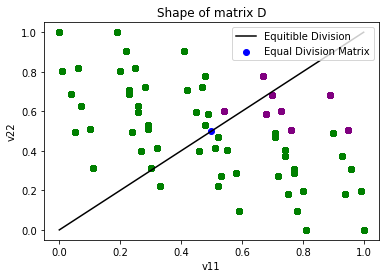

In [7]:
#Making a Random Division Matrix D in set of all D W/ fair area 
def change_d():
  d11= np.random.randint(2)
  if (d11 == 0):
    d21 = 1
  else:
    d21 = 0
  d12 = np.random.randint(2)
  if (d12 == 0):
    d22 = 1
  else:
    d22 = 0
  d13 = np.random.randint(2)
  if (d13 == 0):
    d23 = 1
  else:
    d23 = 0
  d14 = np.random.randint(2) 
  if (d14==0):
    d24 = 1
  else:
    d24 = 0
  d15 = np.random.randint(2)
  if (d15 == 0):
    d25 = 1
  else:
    d25 = 0
  d16 = np.random.randint(2)
  if (d16 == 0):
    d26 =1
  else:
    d26 = 0
  return d11, d12, d13, d14, d15, d16, d21, d22, d23, d24, d25, d26


x=0
T = np.array([
              [.19, .22, .48, .06, .04, .01],
              [0, .095, .22, .18, .31, .195]
  ])
while (x <1000):
  a,b,c,d,e,f,g,h,i,j,k,l = change_d()
  D = np.array([
              [a,b,c,d,e,f],
              [g,h,i,j,k,l]
  ])
#Resultant point from multiplication of division and Prefernce matrix to get utility Matrix, V
  Dt = np.transpose(D)
  V = np.dot(T, Dt)
# Plot v11 v22, to see shape of D
  if (V[0][0]>1/2 and V[1][1] >1/2):
    plt.scatter(V[0][0], V[1][1],  color ='purple')
  else:
    plt.scatter(V[0][0], V[1][1],  color ='green', )
  x = x+1
plt.xlabel('v11')
plt.ylabel('v22')
plt.scatter(.5, .5, color = 'blue', label = "Equal Division Matrix")
plt.plot([0,1], [0,1], color = 'black', label = "Equitible Division")
plt.legend(loc="upper right")
plt.title('Shape of matrix D')
plt.show()